Pricing_Status
Adequate       139
Overpriced      81
Underpriced     80
Name: count, dtype: int64


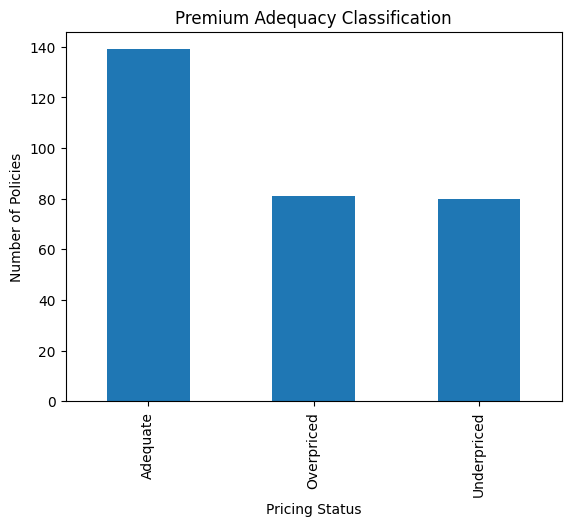

In [2]:

#Underwriting Pricing & Premium Adequacy Engine. A simplified underwriting pricing engine designed to evaluate premium adequacy.
#The model estimates expected losses, applies risk-based loading factors, and evaluates whether the final premium charged is underpriced, adequate, or overpriced relative to the technical premium.

#create a dataset
import pandas as pd
import numpy as np

np.random.seed(42)

num_policies = 300

data = {
    "Policy_ID": range(1, num_policies + 1),
    "Exposure_Value": np.random.randint(50000, 500000, num_policies),
    "Industry_Risk_Score": np.random.randint(1, 10, num_policies),
    "Previous_Claims": np.random.randint(0, 5, num_policies),
    "Base_Loss_Ratio": np.random.uniform(0.3, 0.8, num_policies)
}

df3 = pd.DataFrame(data)

#Calculate expected loss
# Base Loss Ratio  is expected percent of exposure that might be lost.
# Exposure is economic value at risk.

df3["Expected_Loss"] = df3["Exposure_Value"] * df3["Base_Loss_Ratio"]

#Apply risk loading
def risk_loading(row):
    loading = 0.1  # base loading (Expense+profit+contingency margin)

    loading += row["Industry_Risk_Score"] * 0.02
    loading += row["Previous_Claims"] * 0.05

    return loading #this will give value in percent

df3["Loading_Factor"] = df3.apply(risk_loading, axis=1)

#Calculate Technical Premium (increasing the premium with same percentage)
df3["Technical_Premium"] = df3["Expected_Loss"] * (1 + df3["Loading_Factor"])

#Simulate Actual Premium Charged. market pressure affects pricing.Some risks are discounted (competitive pressure), Some are overpriced and Some match technical rate
df3["Premium_Charged"] = df3["Technical_Premium"] * np.random.uniform(0.8, 1.2, num_policies)

# 0.9  & 1.1 are 10% tolerance shows even 10% high or low should not be flagged.
def pricing_flag(row):
    if row["Premium_Charged"] < row["Technical_Premium"]*0.9:
        return "Underpriced"
    elif row["Premium_Charged"] > row["Technical_Premium"] * 1.1:
        return "Overpriced"
    else:
        return "Adequate"

df3["Pricing_Status"] = df3.apply(pricing_flag, axis=1)

# summerize Pricing status
summary = df3["Pricing_Status"].value_counts()
print(summary)

#Visualise Pricing Risk
import matplotlib.pyplot as plt

df3["Pricing_Status"].value_counts().plot(kind="bar")
plt.title("Premium Adequacy Classification")
plt.xlabel("Pricing Status")
plt.ylabel("Number of Policies")
plt.show()
